# `june_events` functions

One cell per library function, then a small combined workflow. See `june_events/CONTEXT.md` for terminology and `june_events/PDR.md` for the function reference.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from june_events import (
    inspect_file,
    load_raw_table,
    load_people_lookup,
    load_venues_lookup,
    load_registry,
    decode_registry_column,
    enrich_with_people,
    enrich_with_venues,
    enrich_with_state_at_time,
    load_enriched_events,
)

EVENTS_PATH = "../runs/plague_more_resp_less_rat/simulation_events.h5"

## `inspect_file` — what's in the file, no data loaded

In [2]:
summary = inspect_file(EVENTS_PATH)
for dataset in summary.datasets:
    print(dataset.path, dataset.n_rows, dataset.dtype)
print("registries:", list(summary.registries))

events/coordinated_encounters 468819614 {'names': ['person_a', 'person_b', 'time', 'encounter_type_id', 'slot', 'group_id'], 'formats': ['<i4', '<i4', '<f8', 'u1', '<i4', '<u8'], 'offsets': [0, 4, 8, 16, 20, 24], 'itemsize': 32}
events/deaths 3135581 [('person_id', '<i4'), ('venue_id', '<i4'), ('time', '<f8')]
events/infections 4415655 {'names': ['person_id', 'infector_id', 'venue_id', 'time', 'encounter_type_id', 'transmission_mode_index', 'infector_symptom_id', 'source'], 'formats': ['<i4', '<i4', '<i4', '<f8', 'u1', 'u1', '<u2', 'u1'], 'offsets': [0, 4, 8, 16, 24, 25, 26, 28], 'itemsize': 32}
events/symptom_changes 14666645 {'names': ['person_id', 'venue_id', 'time', 'old_symptom_id', 'new_symptom_id'], 'formats': ['<i4', '<i4', '<f8', '<u2', '<u2'], 'offsets': [0, 4, 8, 16, 18], 'itemsize': 24}
lookups/people 4412155 {'names': ['person_id', 'age', 'sex', 'geo_unit_id', 'is_dead', 'death_time', 'schedule_type', 'num_activities', 'num_residence_venues', 'num_primary_activities', 'num

## `load_raw_table` — one event type, undecoded

In [3]:
infections = load_raw_table(EVENTS_PATH, "events/infections")
pd.DataFrame(infections)
#infections.head()

,person_id,infector_id,venue_id,time,encounter_type_id,transmission_mode_index,infector_symptom_id,source
0,1806164,-1,-999,1.000000,255,0,0,0
1,2743092,-1,-999,1.000000,255,0,0,0
2,4157331,-1,-999,1.000000,255,0,0,0
3,1741498,-1,-999,1.000000,255,0,0,0
4,754681,-1,-999,1.000000,255,0,0,0
...,...,...,...,...,...,...,...,...
4415650,1330217,-1,1143641,943.375000,0,2,0,2
4415651,1528564,-1,1667190,943.375000,0,2,0,2
4415652,325010,471273,588886,943.541667,255,1,5,0
4415653,484934,698502,971374,943.541667,255,1,5,0


## `load_people_lookup` / `load_venues_lookup`

In [4]:
people = pd.DataFrame(load_people_lookup(EVENTS_PATH))
people


,person_id,age,sex,geo_unit_id,is_dead,death_time,schedule_type,num_activities,num_residence_venues,num_primary_activities,num_leisure_venues,num_medical_facilities,num_sailing_days,num_travel_days,sailor,social_contacts_local,social_contacts_med,social_contacts_near,traveller
0,21906,0.0,female,5601,0,-1.0,standard_worker,5,1,0,0,0,,,,[3324650 3850634 21905 21907 21908],[3000472 617113],[2678206 2833588 3804086 3398839 3931070],
1,21907,0.0,female,5601,0,-1.0,standard_worker,5,1,0,0,0,,,,[1296296 21905 21906 21908 21909],[3000472 252073],[2678208 2678207 2833588 4022971 1536447],
2,21909,0.0,female,5601,0,-1.0,standard_worker,5,1,0,0,0,,,,[4157331 21907 21908 3278229],[252074 678578 252075],[4322244 3486660 4460485 965239 4652220 3931071],
3,97742,0.0,male,5601,0,-1.0,standard_worker,5,1,0,0,0,,,,[3448780 97741 3448782 97743],[545010 545011],[1845992 1845994 2736142 4693519 2444819 4716567],
4,174466,1.0,female,5601,0,-1.0,standard_worker,5,1,0,0,0,,,,[174464 174465 4653955 4134788 3188478],[3367562 3367563],[3515025 800659 603725 1606566],
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4412150,873994,5.0,male,19674,0,-1.0,standard_worker,5,1,0,0,0,,,,[873992 873993 4433858 224678],[4189704 127682 4189701],[4119082 3954738 1827886],
4412151,1663237,11.0,male,19674,0,-1.0,standard_worker,5,1,0,0,0,,,,[3665666 1663236 1663239 1536681 2445016 1788349],[2918675 2918676 4118925],[3423559 127278 49978 49979 49983],
4412152,4747301,83.0,female,19688,0,-1.0,standard_worker,7,1,1,0,0,,,,[1595940 1595941 1595942 4716583 2879578],[569759 277779 569760 4413711],[518481 3860874 4275603 518482],
4412153,661295,4.0,female,19709,0,-1.0,standard_worker,5,1,0,0,0,,,,[1408964 661293 661294 661296 661297],[3297219 2918452],[1386304 1386303],


In [5]:
venues = pd.DataFrame(load_venues_lookup(EVENTS_PATH))
venues

,venue_id,name,type,geo_unit_id,n_subsets
0,-999,infection_seed,infection_seed,-1,0
1,0,Venue_0,church,0,1
2,1,Venue_1,household,0,2
3,2,Venue_2,household,0,2
4,3,Venue_3,household,0,2
...,...,...,...,...,...
1933858,1933857,Venue_1933857,land,19709,1
1933859,1933858,Venue_1933858,land,19709,1
1933860,1933859,Venue_1933859,land,19709,1
1933861,1933860,Venue_1933860,land,19709,1


## `load_registry` / `decode_registry_column` — uint index to label

In [6]:
encounter_types = load_registry(EVENTS_PATH, "encounter_types")
infections["encounter_type"] = decode_registry_column(
    infections, "encounter_type_id", encounter_types
)
infections["encounter_type"].value_counts()

encounter_type
unknown                  3847775
social_contacts_local     389163
social_contacts_near      175721
social_contacts_med         2996
Name: count, dtype: int64

## `enrich_with_people` / `enrich_with_venues` — attach lookup metadata

In [7]:
infections_with_venues = enrich_with_venues(infections, venues)
infections_with_people = enrich_with_people(infections, people)
infections_with_venues[["venue_id", "venue_type", "venue_name"]].head()

,venue_id,venue_type,venue_name
0,-999,infection_seed,infection_seed
1,-999,infection_seed,infection_seed
2,-999,infection_seed,infection_seed
3,-999,infection_seed,infection_seed
4,-999,infection_seed,infection_seed


## `enrich_with_state_at_time` — infector's symptom state at the moment of transmission

In [8]:
symptom_changes = load_raw_table(EVENTS_PATH, "events/symptom_changes")
infections_with_infector_state = pd.DataFrame(
    enrich_with_state_at_time(
    infections, symptom_changes, id_column="infector_id"
)
)
infections_with_infector_state[["infector_id", "time", "new_symptom_id"]]

,infector_id,time,new_symptom_id
0,-1,1.000000,NaN
1,-1,1.000000,NaN
2,-1,1.000000,NaN
3,-1,1.000000,NaN
4,-1,1.000000,NaN
...,...,...,...
4415650,-1,943.375000,NaN
4415651,-1,943.375000,NaN
4415652,471273,943.541667,5.0
4415653,698502,943.541667,5.0


## Combined workflow: infections × symptom_changes → infector symptom at infection, plotted over time

Text(0.5, 1.0, 'Infections per day')

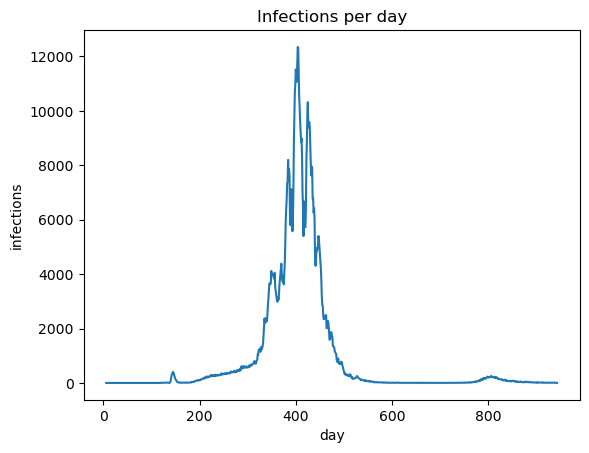

In [9]:
infections = load_raw_table(EVENTS_PATH, "events/infections")
symptom_changes = load_raw_table(EVENTS_PATH, "events/symptom_changes")

symptoms = load_registry(EVENTS_PATH, "symptoms")

enriched = enrich_with_state_at_time(infections, symptom_changes, id_column="infector_id")
enriched = enrich_with_people(enriched, load_people_lookup(EVENTS_PATH))
enriched = enrich_with_venues(enriched, load_venues_lookup(EVENTS_PATH))

# new_symptom_id is NaN where the infector's state was never logged before this instant
# (see PDR.md); decode_registry_column only handles the 255 sentinel, not NaN, so drop first.
enriched = enriched.dropna(subset=["new_symptom_id"]).copy()
enriched["infector_symptom_at_infection"] = decode_registry_column(
    enriched, "new_symptom_id", symptoms
)

infections_per_day = enriched.groupby(enriched["time"].astype(int)).size()

fig, ax = plt.subplots()
infections_per_day.plot(ax=ax)
ax.set_xlabel("day")
ax.set_ylabel("infections")
ax.set_title("Infections per day")

## `load_enriched_events` — load + decode + join, one call

Chains `load_raw_table` -> registry decode (via `DEFAULT_REGISTRY_COLUMNS`) ->
`enrich_with_people` -> `enrich_with_venues`. For notebooks that don't need to
care about file size. Doesn't include `enrich_with_state_at_time` (needs a
second event table the caller must choose) — chain that manually, as above,
when needed.

In [10]:
enriched_infections = load_enriched_events(EVENTS_PATH, "events/infections")
enriched_infections[["encounter_type", "infector_symptom", "venue_type", "person_sex"]].head()

,encounter_type,infector_symptom,venue_type,person_sex
0,unknown,recovered,infection_seed,female
1,unknown,recovered,infection_seed,female
2,unknown,recovered,infection_seed,male
3,unknown,recovered,infection_seed,male
4,unknown,recovered,infection_seed,female
